# EEG 自动对比报告

自动汇总 `processed_data` 下训练报告，输出指标对比、候选模型、消融分析和图表。

In [10]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [CWD, *CWD.parents]:
    if (p / 'processed_data').exists() and (p / 'model_define').exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = CWD

# Allow `import music_eeg...` when notebook runs from subfolders.
pkg_parent = PROJECT_ROOT.parent
if str(pkg_parent) not in sys.path:
    sys.path.insert(0, str(pkg_parent))

ROOT = PROJECT_ROOT / 'processed_data'
REPORT_ROOT = PROJECT_ROOT / 'training_runner' / 'results'
if not REPORT_ROOT.exists():
    REPORT_ROOT = ROOT

print('Project root:', PROJECT_ROOT)
print('Data root:', ROOT)
print('Report root:', REPORT_ROOT)
report_files = sorted([p for p in REPORT_ROOT.glob('*.json') if p.name not in {'split_summary.json', 'nmedt_features.summary.json'}])
print('Found report json:', len(report_files))
for p in report_files:
    print('-', p.name)

Project root: C:\projects\music_eeg\music_eeg
Data root: C:\projects\music_eeg\music_eeg\processed_data
Report root: C:\projects\music_eeg\music_eeg\training_runner\results
Found report json: 5
- ab_test_msresnet_auto.json
- ab_test_resmlp_ce.json
- ab_test_resmlp_focal_onecycle.json
- eeg_1dcnn_report.json
- run_resmlp_focal_onecycle.json


In [11]:
records = []
raw_reports = []
for p in report_files:
    try:
        data = json.loads(p.read_text(encoding='utf-8'))
    except Exception as exc:
        print(f'[skip] {p.name}: {exc}')
        continue
    if not isinstance(data, dict) or 'best_model' not in data:
        continue
    raw_reports.append((p.name, data))
    records.append({
        'report': p.name,
        'best_model': data.get('best_model'),
        'val_acc': data.get('best_val_accuracy', np.nan),
        'test_acc': data.get('test_accuracy', np.nan),
        'test_macro_f1': data.get('test_macro_f1', np.nan),
        'test_balanced_acc': data.get('test_balanced_accuracy', np.nan),
        'model_variant': data.get('model_variant', ''),
        'deep_loss': data.get('deep_loss', ''),
        'use_onecycle': data.get('use_onecycle', False),
        'run_classical_models': data.get('run_classical_models', None)
    })

summary_df = pd.DataFrame(records)
if summary_df.empty:
    print('No valid report records found. Check report path or report schema.')
else:
    summary_df = summary_df.sort_values(['test_macro_f1', 'val_acc'], ascending=False)
summary_df

,report,best_model,val_acc,test_acc,test_macro_f1,test_balanced_acc,model_variant,deep_loss,use_onecycle,run_classical_models
3,eeg_1dcnn_report.json,eeg_msresnet,0.997099,0.997099,0.997091,0.997108,msresnet,focal,True,False
4,run_resmlp_focal_onecycle.json,eeg_resmlp,0.390383,0.328235,0.302792,0.326629,resmlp,focal,True,False
2,ab_test_resmlp_focal_onecycle.json,eeg_resmlp,0.356013,0.291315,0.270325,0.290492,resmlp,focal,True,False
1,ab_test_resmlp_ce.json,eeg_resmlp,0.337641,0.267053,0.247583,0.265948,resmlp,ce,False,False
0,ab_test_msresnet_auto.json,eeg_msresnet,0.099156,0.089575,0.068299,0.090864,msresnet,auto,True,False


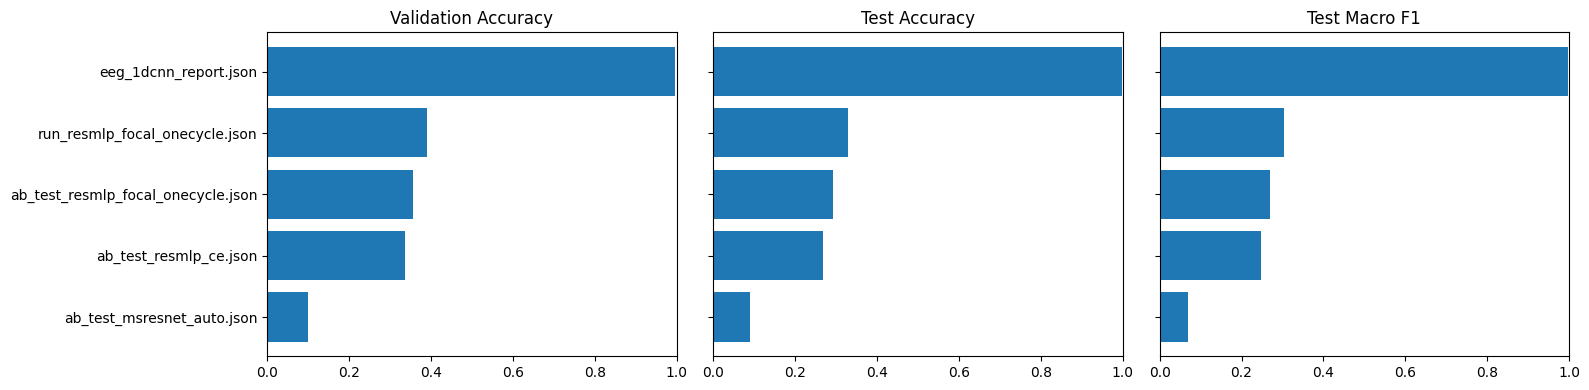

In [12]:
if not summary_df.empty:
    show_df = summary_df.head(min(10, len(summary_df))).iloc[::-1]
    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(show_df) * 0.6)), sharey=True)
    axes[0].barh(show_df['report'], show_df['val_acc'])
    axes[0].set_title('Validation Accuracy')
    axes[0].set_xlim(0, 1)
    axes[1].barh(show_df['report'], show_df['test_acc'])
    axes[1].set_title('Test Accuracy')
    axes[1].set_xlim(0, 1)
    axes[2].barh(show_df['report'], show_df['test_macro_f1'])
    axes[2].set_title('Test Macro F1')
    axes[2].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print('No valid reports found.')

In [13]:
candidate_rows = []
for name, data in raw_reports:
    for c in (data.get('all_candidates') or []):
        candidate_rows.append({
            'report': name,
            'candidate': c.get('name'),
            'val_acc': c.get('val_acc', np.nan),
            'robust_score_mean': c.get('robust_score_mean', np.nan),
            'val_acc_std': c.get('val_acc_std', np.nan)
        })
cand_df = pd.DataFrame(candidate_rows)
cand_df.sort_values(['report', 'val_acc'], ascending=[True, False]).head(40) if not cand_df.empty else 'No all_candidates in reports'

,report,candidate,val_acc,robust_score_mean,val_acc_std
0,ab_test_msresnet_auto.json,eeg_msresnet,0.099156,0.099156,0.0
1,ab_test_msresnet_auto.json,ensemble_top3_weighted,0.099156,0.099156,0.0
2,ab_test_resmlp_ce.json,eeg_resmlp,0.337641,0.337641,0.0
3,ab_test_resmlp_ce.json,ensemble_top3_weighted,0.337641,0.337641,0.0
4,ab_test_resmlp_focal_onecycle.json,eeg_resmlp,0.356013,0.356013,0.0
5,ab_test_resmlp_focal_onecycle.json,ensemble_top3_weighted,0.356013,0.356013,0.0
6,eeg_1dcnn_report.json,eeg_msresnet,0.997099,0.997099,0.0
7,eeg_1dcnn_report.json,ensemble_top3_weighted,0.997099,0.997099,0.0
8,run_resmlp_focal_onecycle.json,eeg_resmlp,0.390383,0.390383,0.0
9,run_resmlp_focal_onecycle.json,ensemble_top3_weighted,0.390383,0.390383,0.0


In [14]:
ablation_rows = []
for name, data in raw_reports:
    for a in (data.get('feature_ablation') or []):
        ablation_rows.append({
            'report': name,
            'ablation': a.get('name'),
            'n_features': a.get('n_features', np.nan),
            'val_acc_mean': a.get('val_acc_mean', np.nan),
            'val_macro_f1_mean': a.get('val_macro_f1_mean', np.nan),
            'val_balanced_acc_mean': a.get('val_balanced_acc_mean', np.nan)
        })
ablation_df = pd.DataFrame(ablation_rows)

if ablation_df.empty:
    print('Report中无消融结果，自动补跑一次轻量消融(seed=42)...')
    try:
        from music_eeg.model_define.data_utils import load_split
        from music_eeg.model_define.evaluation import run_feature_ablation
    except ModuleNotFoundError:
        from model_define.data_utils import load_split
        from model_define.evaluation import run_feature_ablation
    from sklearn.preprocessing import LabelEncoder

    x_train, y_train = load_split(ROOT / 'train_features.csv')
    x_val, y_val = load_split(ROOT / 'val_features.csv')
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)
    live_ablation = run_feature_ablation(x_train, y_train_enc, x_val, y_val_enc, seeds=[42])
    ablation_df = pd.DataFrame(live_ablation)
    if not ablation_df.empty:
        ablation_df.insert(0, 'report', 'live_ablation_seed42')

ablation_df

Report中无消融结果，自动补跑一次轻量消融(seed=42)...


""


In [15]:
if not ablation_df.empty:
    p = ablation_df.sort_values('val_acc_mean', ascending=False).head(12).iloc[::-1]
    plt.figure(figsize=(10, max(4, len(p) * 0.45)))
    plt.barh(p['ablation'], p['val_acc_mean'])
    plt.title('Feature Ablation (Validation Accuracy)')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print('Ablation result is empty.')

Ablation result is empty.


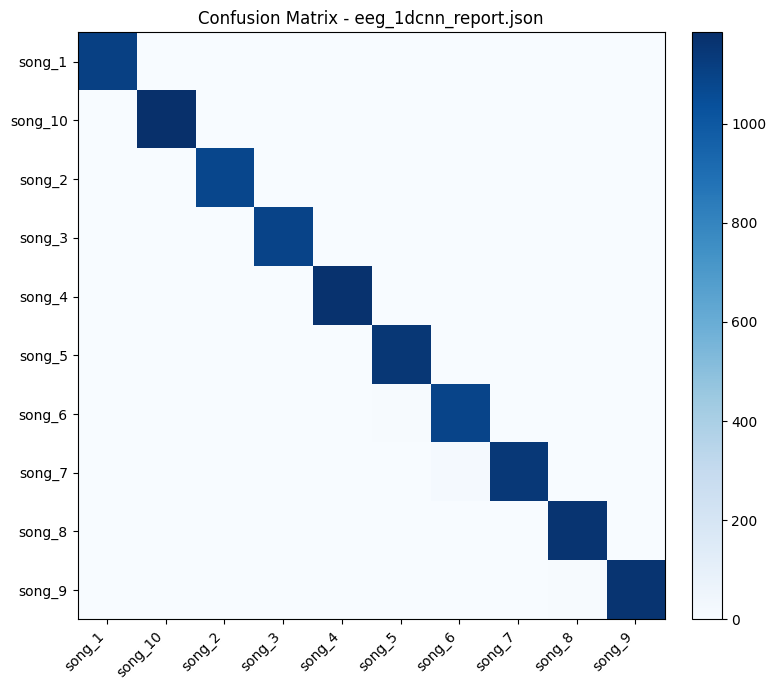

In [16]:
if summary_df.empty:
    print('No report to visualize confusion matrix.')
else:
    best_name = summary_df.iloc[0]['report']
    best_data = next(d for n, d in raw_reports if n == best_name)
    cm = np.array(best_data.get('confusion_matrix', []), dtype=float)
    if cm.size == 0:
        print('Best report has no confusion matrix.')
    else:
        classes = best_data.get('classes', [str(i) for i in range(cm.shape[0])])
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha='right')
        ax.set_yticklabels(classes)
        ax.set_title(f'Confusion Matrix - {best_name}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

# EEG Model Comparison Report

本 notebook 会自动扫描 `processed_data` 目录中的训练报告（`*.json`），并输出：
- 关键指标对比（val/test/macro_f1）
- 候选模型排名对比
- 消融实验汇总（报告内 + 自动补跑）
- 最优报告的混淆矩阵可视化

In [17]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [CWD, *CWD.parents]:
    if (p / 'processed_data').exists() and (p / 'model_define').exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = CWD

pkg_parent = PROJECT_ROOT.parent
if str(pkg_parent) not in sys.path:
    sys.path.insert(0, str(pkg_parent))

ROOT = PROJECT_ROOT / 'processed_data'
REPORT_ROOT = PROJECT_ROOT / 'training_runner' / 'results'
if not REPORT_ROOT.exists():
    REPORT_ROOT = ROOT

print('Project root:', PROJECT_ROOT)
print('Data root:', ROOT)
print('Report root:', REPORT_ROOT)
report_files = sorted([p for p in REPORT_ROOT.glob('*.json') if p.name not in {'split_summary.json', 'nmedt_features.summary.json'}])
print('Found reports:', len(report_files))
for p in report_files:
    print('-', p.name)

Project root: C:\projects\music_eeg\music_eeg
Data root: C:\projects\music_eeg\music_eeg\processed_data
Report root: C:\projects\music_eeg\music_eeg\training_runner\results
Found reports: 6
- ab_test_msresnet_auto.json
- ab_test_resmlp_ce.json
- ab_test_resmlp_focal_onecycle.json
- eeg_1dcnn_report.json
- run_msresnet_focal_onecycle.json
- run_resmlp_focal_onecycle.json


In [18]:
records = []
raw_reports = []
for p in report_files:
    try:
        data = json.loads(p.read_text(encoding='utf-8'))
    except Exception as exc:
        print(f'[skip] {p.name}: {exc}')
        continue

    if not isinstance(data, dict) or 'best_model' not in data:
        continue

    raw_reports.append((p.name, data))
    records.append({
        'report': p.name,
        'best_model': data.get('best_model'),
        'val_acc': data.get('best_val_accuracy', np.nan),
        'test_acc': data.get('test_accuracy', np.nan),
        'test_macro_f1': data.get('test_macro_f1', np.nan),
        'test_balanced_acc': data.get('test_balanced_accuracy', np.nan),
        'model_variant': data.get('model_variant', ''),
        'deep_loss': data.get('deep_loss', ''),
        'use_onecycle': data.get('use_onecycle', False),
        'epochs': data.get('epochs', None),
        'run_classical_models': data.get('run_classical_models', None),
    })

summary_df = pd.DataFrame(records)
if summary_df.empty:
    print('No valid report records found. Check report path or report schema.')
else:
    summary_df = summary_df.sort_values(['test_macro_f1', 'val_acc'], ascending=False)
summary_df

,report,best_model,val_acc,test_acc,test_macro_f1,test_balanced_acc,model_variant,deep_loss,use_onecycle,epochs,run_classical_models
4,run_msresnet_focal_onecycle.json,eeg_msresnet,1.000000,0.999648,0.999648,0.999640,msresnet,focal,True,None,False
3,eeg_1dcnn_report.json,eeg_msresnet,0.997099,0.997099,0.997091,0.997108,msresnet,focal,True,None,False
5,run_resmlp_focal_onecycle.json,eeg_resmlp,0.390383,0.328235,0.302792,0.326629,resmlp,focal,True,None,False
2,ab_test_resmlp_focal_onecycle.json,eeg_resmlp,0.356013,0.291315,0.270325,0.290492,resmlp,focal,True,None,False
1,ab_test_resmlp_ce.json,eeg_resmlp,0.337641,0.267053,0.247583,0.265948,resmlp,ce,False,None,False
0,ab_test_msresnet_auto.json,eeg_msresnet,0.099156,0.089575,0.068299,0.090864,msresnet,auto,True,None,False


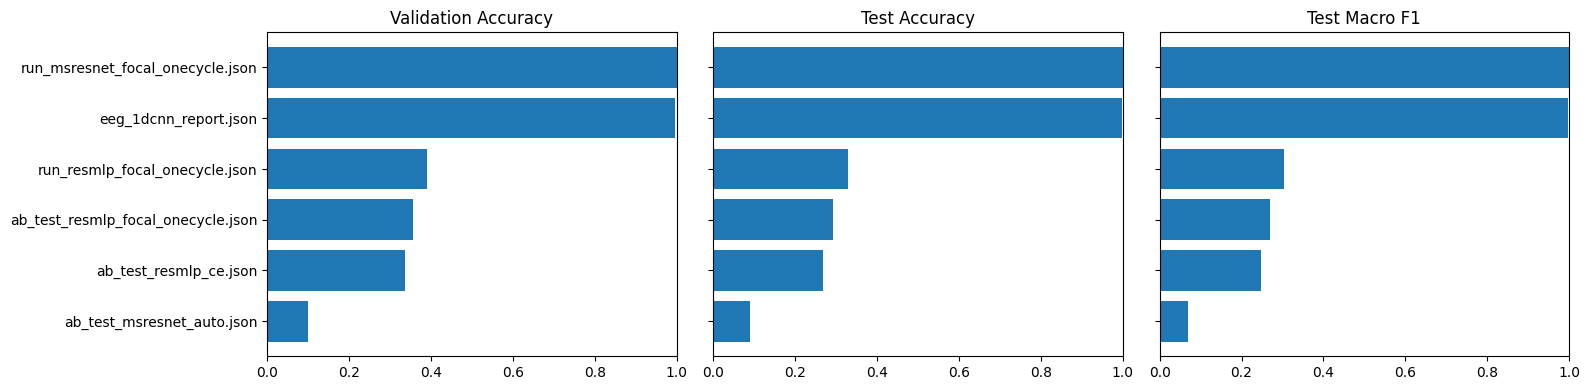

In [19]:
if not summary_df.empty:
    top_n = min(8, len(summary_df))
    plot_df = summary_df.head(top_n).copy()
    plot_df = plot_df.iloc[::-1]

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, top_n * 0.6)), sharey=True)

    axes[0].barh(plot_df['report'], plot_df['val_acc'])
    axes[0].set_title('Validation Accuracy')
    axes[0].set_xlim(0, 1)

    axes[1].barh(plot_df['report'], plot_df['test_acc'])
    axes[1].set_title('Test Accuracy')
    axes[1].set_xlim(0, 1)

    axes[2].barh(plot_df['report'], plot_df['test_macro_f1'])
    axes[2].set_title('Test Macro F1')
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()
else:
    print('No valid report json found for plotting.')

In [20]:
candidate_rows = []
for name, data in raw_reports:
    for c in data.get('all_candidates', []) or []:
        candidate_rows.append({
            'report': name,
            'candidate': c.get('name'),
            'val_acc': c.get('val_acc', np.nan),
            'robust_score_mean': c.get('robust_score_mean', np.nan),
            'val_acc_std': c.get('val_acc_std', np.nan),
        })

cand_df = pd.DataFrame(candidate_rows)
if cand_df.empty:
    print('No all_candidates found in reports.')
else:
    display(cand_df.sort_values(['report', 'val_acc'], ascending=[True, False]).head(30))

,report,candidate,val_acc,robust_score_mean,val_acc_std
0,ab_test_msresnet_auto.json,eeg_msresnet,0.099156,0.099156,0.0
1,ab_test_msresnet_auto.json,ensemble_top3_weighted,0.099156,0.099156,0.0
2,ab_test_resmlp_ce.json,eeg_resmlp,0.337641,0.337641,0.0
3,ab_test_resmlp_ce.json,ensemble_top3_weighted,0.337641,0.337641,0.0
4,ab_test_resmlp_focal_onecycle.json,eeg_resmlp,0.356013,0.356013,0.0
5,ab_test_resmlp_focal_onecycle.json,ensemble_top3_weighted,0.356013,0.356013,0.0
6,eeg_1dcnn_report.json,eeg_msresnet,0.997099,0.997099,0.0
7,eeg_1dcnn_report.json,ensemble_top3_weighted,0.997099,0.997099,0.0
8,run_msresnet_focal_onecycle.json,eeg_msresnet,1.000000,1.000000,0.0
9,run_msresnet_focal_onecycle.json,ensemble_top3_weighted,1.000000,1.000000,0.0


In [21]:
ablation_rows = []
for name, data in raw_reports:
    for a in data.get('feature_ablation', []) or []:
        ablation_rows.append({
            'report': name,
            'ablation': a.get('name'),
            'n_features': a.get('n_features', np.nan),
            'val_acc_mean': a.get('val_acc_mean', np.nan),
            'val_macro_f1_mean': a.get('val_macro_f1_mean', np.nan),
            'val_balanced_acc_mean': a.get('val_balanced_acc_mean', np.nan),
        })

ablation_df = pd.DataFrame(ablation_rows)
if ablation_df.empty:
    print('No ablation results inside report files. Running one lightweight ablation now...')
    try:
        from music_eeg.model_define.data_utils import load_split
        from music_eeg.model_define.evaluation import run_feature_ablation
    except ModuleNotFoundError:
        from model_define.data_utils import load_split
        from model_define.evaluation import run_feature_ablation
    from sklearn.preprocessing import LabelEncoder

    data_dir = ROOT
    x_train, y_train = load_split(data_dir / 'train_features.csv')
    x_val, y_val = load_split(data_dir / 'val_features.csv')
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)

    ablation = run_feature_ablation(x_train, y_train_enc, x_val, y_val_enc, seeds=[42])
    ablation_df = pd.DataFrame(ablation)
    if not ablation_df.empty:
        ablation_df.insert(0, 'report', 'live_ablation_seed42')

ablation_df

No ablation results inside report files. Running one lightweight ablation now...


""


In [22]:
if not ablation_df.empty:
    best_ablation = ablation_df.sort_values('val_acc_mean', ascending=False).head(12).copy()
    best_ablation = best_ablation.iloc[::-1]

    plt.figure(figsize=(10, max(4, len(best_ablation) * 0.45)))
    plt.barh(best_ablation['ablation'], best_ablation['val_acc_mean'])
    plt.xlim(0, 1)
    plt.title('Feature Ablation (Validation Accuracy)')
    plt.tight_layout()
    plt.show()
else:
    print('Ablation table is empty.')

Ablation table is empty.


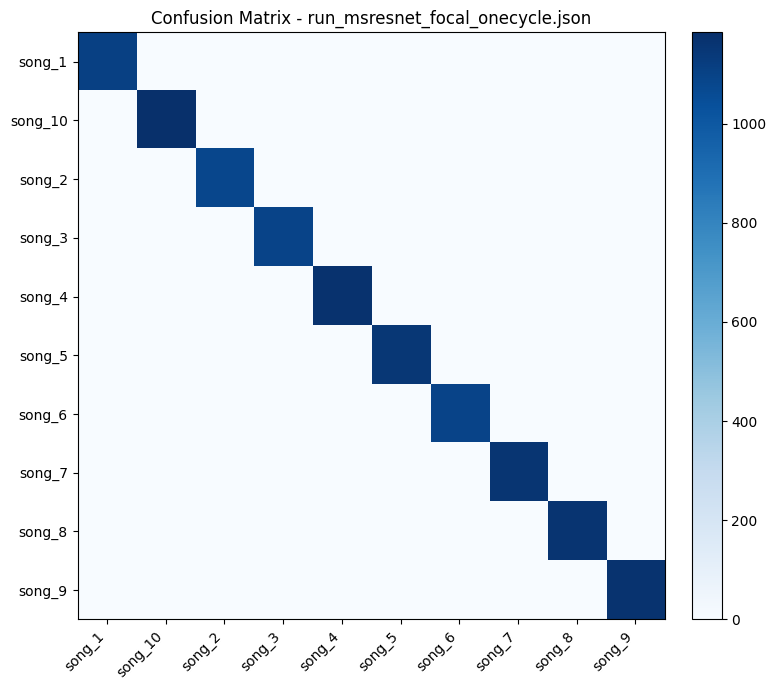

In [23]:
if summary_df.empty:
    print('No report found for confusion matrix preview.')
else:
    best_report_name = summary_df.iloc[0]['report']
    best_data = next(d for n, d in raw_reports if n == best_report_name)
    cm = np.array(best_data.get('confusion_matrix', []), dtype=float)
    classes = best_data.get('classes', [str(i) for i in range(cm.shape[0])])

    if cm.size == 0:
        print('Best report has no confusion matrix.')
    else:
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45, ha='right')
        ax.set_yticklabels(classes)
        ax.set_title(f'Confusion Matrix - {best_report_name}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()